In [1]:
import os
import json
import numpy as np
import librosa
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================
DATASET_PATH = "/Users/canpasa_macmini_2025/Desktop/New Paper GTZAN/GTZAN DATA/genres_original"
OUTPUT_PATH = "extracted_features"

SR = 22050
TRACK_DURATION = 30       # orijinal dosya süresi
SEGMENT_DURATION = 3      # her segmentin süresi
N_MELS = 128

N_FFT_VALUES = [512, 1024, 2048]
HOP_LENGTH_VALUES = [128, 256, 512]

AUDIO_EXTENSIONS = (".wav", ".mp3", ".flac", ".ogg", ".aiff", ".aif", ".m4a")

# =========================================================
# AUDIO FUNCTIONS
# =========================================================
def load_full_audio(file_path, sr=22050, track_duration=30):
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_length = int(sr * track_duration)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode="constant")
    else:
        y = y[:target_length]

    return y


def split_into_segments(y, sr=22050, segment_duration=3):
    segment_length = int(sr * segment_duration)
    total_segments = len(y) // segment_length

    segments = []
    for i in range(total_segments):
        start = i * segment_length
        end = start + segment_length
        segment = y[start:end]
        segments.append(segment)

    return segments


def extract_log_mel_spectrogram(
    y,
    sr=22050,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
):
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        n_mels=n_mels,
        power=2.0
    )

    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    mean = np.mean(log_mel)
    std = np.std(log_mel)
    if std < 1e-8:
        std = 1e-8

    log_mel = (log_mel - mean) / std
    log_mel = np.expand_dims(log_mel, axis=-1).astype(np.float32)

    return log_mel

# =========================================================
# DATASET SCAN
# =========================================================
def get_class_folders(dataset_path):
    class_names = [
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ]
    class_names.sort()
    return class_names


def collect_audio_files(dataset_path):
    class_names = get_class_folders(dataset_path)
    label_map = {class_name: idx for idx, class_name in enumerate(class_names)}

    file_records = []
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        for root, _, files in os.walk(class_dir):
            for file in files:
                if file.lower().endswith(AUDIO_EXTENSIONS):
                    file_path = os.path.join(root, file)
                    file_records.append((file_path, class_name))

    return file_records, label_map

# =========================================================
# EXTRACTION
# =========================================================
def extract_and_save_features_for_config(
    file_records,
    label_map,
    output_root,
    sr=22050,
    track_duration=30,
    segment_duration=3,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
):
    config_name = f"fft{n_fft}_hop{hop_length}_mel{n_mels}_seg{segment_duration}"
    save_dir = os.path.join(output_root, config_name)
    os.makedirs(save_dir, exist_ok=True)

    X_list = []
    y_list = []
    bad_files = []

    print(f"\n[INFO] Processing config: {config_name}")

    for file_path, class_name in tqdm(file_records, desc=config_name):
        try:
            y_full = load_full_audio(
                file_path=file_path,
                sr=sr,
                track_duration=track_duration
            )

            segments = split_into_segments(
                y_full,
                sr=sr,
                segment_duration=segment_duration
            )

            for segment in segments:
                feature = extract_log_mel_spectrogram(
                    y=segment,
                    sr=sr,
                    n_fft=n_fft,
                    hop_length=hop_length,
                    n_mels=n_mels
                )

                X_list.append(feature)
                y_list.append(label_map[class_name])

        except Exception as e:
            bad_files.append({"file": file_path, "error": str(e)})

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)

    np.save(os.path.join(save_dir, "X.npy"), X)
    np.save(os.path.join(save_dir, "y.npy"), y)

    with open(os.path.join(save_dir, "label_map.json"), "w", encoding="utf-8") as f:
        json.dump(label_map, f, indent=4, ensure_ascii=False)

    meta = {
        "dataset_path": os.path.abspath(DATASET_PATH),
        "num_samples": int(len(y)),
        "input_shape": list(X.shape[1:]),
        "sr": sr,
        "track_duration": track_duration,
        "segment_duration": segment_duration,
        "segments_per_track": int(track_duration // segment_duration),
        "n_fft": n_fft,
        "hop_length": hop_length,
        "n_mels": n_mels,
        "num_classes": len(label_map),
        "classes": list(label_map.keys()),
        "bad_file_count": len(bad_files),
    }

    with open(os.path.join(save_dir, "meta.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=4, ensure_ascii=False)

    if bad_files:
        with open(os.path.join(save_dir, "bad_files.json"), "w", encoding="utf-8") as f:
            json.dump(bad_files, f, indent=4, ensure_ascii=False)

    print(f"[SAVED] {save_dir}")
    print(f"        X shape: {X.shape}")
    print(f"        y shape: {y.shape}")
    print(f"        bad files: {len(bad_files)}")

# =========================================================
# MAIN
# =========================================================
def main():
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    print("[INFO] Scanning dataset...")
    file_records, label_map = collect_audio_files(DATASET_PATH)

    print(f"[INFO] Total audio files found: {len(file_records)}")
    print(f"[INFO] Classes: {label_map}")

    if len(file_records) == 0:
        raise ValueError("No audio files found. Check DATASET_PATH and file extensions.")

    for n_fft in N_FFT_VALUES:
        for hop_length in HOP_LENGTH_VALUES:
            extract_and_save_features_for_config(
                file_records=file_records,
                label_map=label_map,
                output_root=OUTPUT_PATH,
                sr=SR,
                track_duration=TRACK_DURATION,
                segment_duration=SEGMENT_DURATION,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=N_MELS
            )

    print("\n[INFO] All feature extraction processes completed successfully.")


if __name__ == "__main__":
    main()

[INFO] Scanning dataset...
[INFO] Total audio files found: 1000
[INFO] Classes: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}

[INFO] Processing config: fft512_hop128_mel128_seg3


fft512_hop128_mel128_seg3:  54%|█████▍    | 542/1000 [00:20<00:14, 31.18it/s]/var/folders/0f/vhsb8bzd71lbnj5mxjqkk23h0000gn/T/ipykernel_4150/2881800093.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr, mono=True)
/opt/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
fft512_hop128_mel128_seg3: 100%|██████████| 1000/1000 [00:36<00:00, 27.52it/s]


[SAVED] extracted_features/fft512_hop128_mel128_seg3
        X shape: (9990, 128, 517, 1)
        y shape: (9990,)
        bad files: 1

[INFO] Processing config: fft512_hop256_mel128_seg3


fft512_hop256_mel128_seg3: 100%|██████████| 1000/1000 [00:49<00:00, 20.17it/s]


[SAVED] extracted_features/fft512_hop256_mel128_seg3
        X shape: (9990, 128, 259, 1)
        y shape: (9990,)
        bad files: 1

[INFO] Processing config: fft512_hop512_mel128_seg3


...

[SAVED] extracted_features/fft2048_hop128_mel128_seg3
        X shape: (9990, 128, 517, 1)
        y shape: (9990,)
        bad files: 1

[INFO] Processing config: fft2048_hop256_mel128_seg3


fft2048_hop256_mel128_seg3: 100%|██████████| 1000/1000 [01:01<00:00, 16.17it/s]


[SAVED] extracted_features/fft2048_hop256_mel128_seg3
        X shape: (9990, 128, 259, 1)
        y shape: (9990,)
        bad files: 1

[INFO] Processing config: fft2048_hop512_mel128_seg3


fft2048_hop512_mel128_seg3: 100%|██████████| 1000/1000 [00:43<00:00, 23.04it/s]


[SAVED] extracted_features/fft2048_hop512_mel128_seg3
        X shape: (9990, 128, 130, 1)
        y shape: (9990,)
        bad files: 1

[INFO] All feature extraction processes completed successfully.


In [6]:
import os
import numpy as np
import json

FEATURE_ROOT = "extracted_features"

folders = sorted(os.listdir(FEATURE_ROOT))

print("\n===== FEATURE DATASET CHECK =====\n")

for folder in folders:

    folder_path = os.path.join(FEATURE_ROOT, folder)

    if not os.path.isdir(folder_path):
        continue

    print(f"\nDataset: {folder}")
    print("-" * 40)

    X_path = os.path.join(folder_path, "X.npy")
    y_path = os.path.join(folder_path, "y.npy")

    X = np.load(X_path)
    y = np.load(y_path)

    print("X shape:", X.shape)
    print("y shape:", y.shape)

    # NaN / Inf kontrol
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()

    print("NaN count:", nan_count)
    print("Inf count:", inf_count)

    # class distribution
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique, counts))

    print("Class distribution:", dist)

    # meta bilgisi
    meta_path = os.path.join(folder_path, "meta.json")
    if os.path.exists(meta_path):

        with open(meta_path) as f:
            meta = json.load(f)

        print("n_fft:", meta["n_fft"])
        print("hop_length:", meta["hop_length"])
        print("samples:", meta["num_samples"])

print("\n===== CHECK COMPLETED =====")


===== FEATURE DATASET CHECK =====


Dataset: fft1024_hop128_mel128_seg3
----------------------------------------
X shape: (9990, 128, 517, 1)
y shape: (9990,)
NaN count: 0
Inf count: 0
Class distribution: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 990, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
n_fft: 1024
hop_length: 128
samples: 9990

Dataset: fft1024_hop256_mel128_seg3
----------------------------------------
X shape: (9990, 128, 259, 1)
y shape: (9990,)
NaN count: 0
Inf count: 0
Class distribution: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 990, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
n_fft: 1024
hop_length: 256
samples: 9990

Dataset: fft1024_hop512_mel128_seg3
----------------------------------------
X shape: (9990, 128, 130, 1)
y shape: (9990,)
NaN count: 0
Inf count: 0
Class distribution: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 990, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
n_fft: 1024
hop_length: 512
samples: 9990

Dataset: fft2048_hop128_mel128_seg3
---------------------

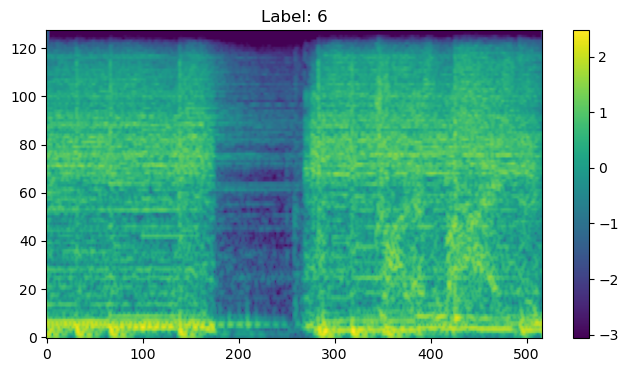

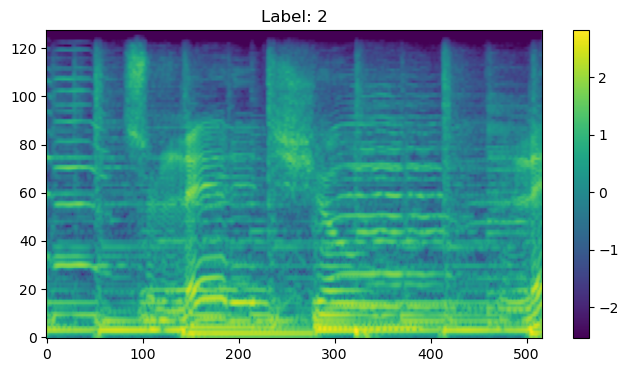

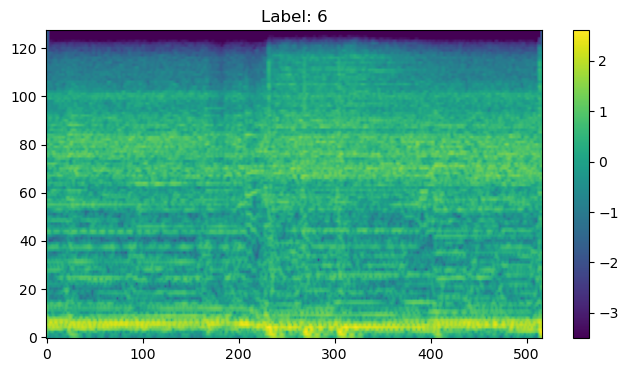

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

X = np.load("extracted_features/fft1024_hop128_mel128_seg3/X.npy")
y = np.load("extracted_features/fft1024_hop128_mel128_seg3/y.npy")

for _ in range(3):
    i = random.randint(0, len(X)-1)
    plt.figure(figsize=(8, 4))
    plt.imshow(X[i, :, :, 0], aspect="auto", origin="lower")
    plt.title(f"Label: {y[i]}")
    plt.colorbar()
    plt.show()

In [1]:
import os
import json
import numpy as np
import librosa
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================
DATASET_PATH = "/Users/canpasa_macmini_2025/Desktop/New Paper GTZAN/GTZAN DATA/genres_original"
OUTPUT_PATH = "extracted_features_with_segments_new"

SR = 22050
TRACK_DURATION = 30
SEGMENT_DURATION = 3
N_MELS = 128

N_FFT_VALUES = [512, 1024, 2048]
HOP_LENGTH_VALUES = [128, 256, 512]

AUDIO_EXTENSIONS = (".wav", ".mp3", ".flac", ".ogg", ".aiff", ".aif", ".m4a")

# =========================================================
# AUDIO FUNCTIONS
# =========================================================
def load_full_audio(file_path, sr=22050, track_duration=30):
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_length = int(sr * track_duration)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode="constant")
    else:
        y = y[:target_length]

    return y


def split_into_segments(y, sr=22050, segment_duration=3):
    segment_length = int(sr * segment_duration)
    total_segments = len(y) // segment_length

    segments = []
    for i in range(total_segments):
        start = i * segment_length
        end = start + segment_length
        segments.append(y[start:end])

    return segments


def extract_log_mel_spectrogram(y, sr=22050, n_fft=1024, hop_length=256, n_mels=128):
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        n_mels=n_mels,
        power=2.0
    )

    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    mean = np.mean(log_mel)
    std = np.std(log_mel)
    if std < 1e-8:
        std = 1e-8

    log_mel = (log_mel - mean) / std
    log_mel = np.expand_dims(log_mel, axis=-1).astype(np.float32)

    return log_mel

# =========================================================
# DATASET SCAN
# =========================================================
def get_class_folders(dataset_path):
    class_names = [
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ]
    class_names.sort()
    return class_names


def collect_audio_files(dataset_path):
    class_names = get_class_folders(dataset_path)
    label_map = {class_name: idx for idx, class_name in enumerate(class_names)}

    file_records = []
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        for root, _, files in os.walk(class_dir):
            for file in files:
                if file.lower().endswith(AUDIO_EXTENSIONS):
                    file_path = os.path.join(root, file)
                    file_records.append((file_path, class_name))

    return file_records, label_map

# =========================================================
# EXTRACTION + SAVE
# =========================================================
def extract_and_save_features_for_config(
    file_records,
    label_map,
    output_root,
    sr=22050,
    track_duration=30,
    segment_duration=3,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
):
    config_name = f"fft{n_fft}_hop{hop_length}_mel{n_mels}_seg{segment_duration}"
    save_dir = os.path.join(output_root, config_name)
    os.makedirs(save_dir, exist_ok=True)

    X_list = []
    y_list = []
    segment_records = []
    bad_files = []

    print(f"\n[INFO] Processing config: {config_name}")

    for file_path, class_name in tqdm(file_records, desc=config_name):
        try:
            y_full = load_full_audio(
                file_path=file_path,
                sr=sr,
                track_duration=track_duration
            )

            segments = split_into_segments(
                y_full,
                sr=sr,
                segment_duration=segment_duration
            )

            for seg_idx, segment in enumerate(segments):
                feature = extract_log_mel_spectrogram(
                    y=segment,
                    sr=sr,
                    n_fft=n_fft,
                    hop_length=hop_length,
                    n_mels=n_mels
                )

                X_list.append(feature)
                y_list.append(label_map[class_name])

                segment_records.append({
                    "track_path": file_path,
                    "class_name": class_name,
                    "segment_index": seg_idx
                })

        except Exception as e:
            bad_files.append({"file": file_path, "error": str(e)})

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)

    np.save(os.path.join(save_dir, "X.npy"), X)
    np.save(os.path.join(save_dir, "y.npy"), y)

    with open(os.path.join(save_dir, "label_map.json"), "w", encoding="utf-8") as f:
        json.dump(label_map, f, indent=4, ensure_ascii=False)

    with open(os.path.join(save_dir, "segments.json"), "w", encoding="utf-8") as f:
        json.dump(segment_records, f, indent=2, ensure_ascii=False)

    meta = {
        "dataset_path": os.path.abspath(DATASET_PATH),
        "num_tracks": len(file_records),
        "num_samples": int(len(y)),
        "input_shape": list(X.shape[1:]),
        "sr": sr,
        "track_duration": track_duration,
        "segment_duration": segment_duration,
        "segments_per_track": int(track_duration // segment_duration),
        "n_fft": n_fft,
        "hop_length": hop_length,
        "n_mels": n_mels,
        "num_classes": len(label_map),
        "classes": list(label_map.keys()),
        "bad_file_count": len(bad_files),
    }

    with open(os.path.join(save_dir, "meta.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=4, ensure_ascii=False)

    if bad_files:
        with open(os.path.join(save_dir, "bad_files.json"), "w", encoding="utf-8") as f:
            json.dump(bad_files, f, indent=4, ensure_ascii=False)

    print(f"[SAVED] {save_dir}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"segments saved: {len(segment_records)}")
    print(f"bad files: {len(bad_files)}")

# =========================================================
# MAIN
# =========================================================
def main():
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    print("[INFO] Scanning dataset...")
    file_records, label_map = collect_audio_files(DATASET_PATH)

    print(f"[INFO] Total tracks found: {len(file_records)}")
    print(f"[INFO] Classes: {label_map}")

    for n_fft in N_FFT_VALUES:
        for hop_length in HOP_LENGTH_VALUES:
            extract_and_save_features_for_config(
                file_records=file_records,
                label_map=label_map,
                output_root=OUTPUT_PATH,
                sr=SR,
                track_duration=TRACK_DURATION,
                segment_duration=SEGMENT_DURATION,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=N_MELS
            )

    print("\n[INFO] All feature extraction processes completed successfully.")

if __name__ == "__main__":
    main()

[INFO] Scanning dataset...
[INFO] Total tracks found: 1000
[INFO] Classes: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}

[INFO] Processing config: fft512_hop128_mel128_seg3


fft512_hop128_mel128_seg3:  54%|█████▍    | 544/1000 [00:18<00:15, 29.16it/s]/var/folders/0f/vhsb8bzd71lbnj5mxjqkk23h0000gn/T/ipykernel_3352/635846245.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=sr, mono=True)
/opt/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
fft512_hop128_mel128_seg3: 100%|██████████| 1000/1000 [00:38<00:00, 25.95it/s]


[SAVED] extracted_features_with_segments_new/fft512_hop128_mel128_seg3
X shape: (9990, 128, 517, 1)
y shape: (9990,)
segments saved: 9990
bad files: 1

[INFO] Processing config: fft512_hop256_mel128_seg3


fft512_hop256_mel128_seg3: 100%|██████████| 1000/1000 [00:31<00:00, 32.05it/s]


[SAVED] extracted_features_with_segments_new/fft512_hop256_mel128_seg3
X shape: (9990, 128, 259, 1)
y shape: (9990,)
segments saved: 9990
bad files: 1

[INFO] Processing config: fft512_hop512_mel128_seg3


...

[SAVED] extracted_features_with_segments_new/fft2048_hop128_mel128_seg3
X shape: (9990, 128, 517, 1)
y shape: (9990,)
segments saved: 9990
bad files: 1

[INFO] Processing config: fft2048_hop256_mel128_seg3


fft2048_hop256_mel128_seg3: 100%|██████████| 1000/1000 [00:54<00:00, 18.42it/s]


[SAVED] extracted_features_with_segments_new/fft2048_hop256_mel128_seg3
X shape: (9990, 128, 259, 1)
y shape: (9990,)
segments saved: 9990
bad files: 1

[INFO] Processing config: fft2048_hop512_mel128_seg3


fft2048_hop512_mel128_seg3: 100%|██████████| 1000/1000 [00:42<00:00, 23.73it/s]


[SAVED] extracted_features_with_segments_new/fft2048_hop512_mel128_seg3
X shape: (9990, 128, 130, 1)
y shape: (9990,)
segments saved: 9990
bad files: 1

[INFO] All feature extraction processes completed successfully.


In [2]:
import os
import json
import numpy as np

FEATURE_ROOT = "/Users/canpasa_macmini_2025/Desktop/New Paper GTZAN/extracted_features_with_segments_new"  # gerekiyorsa değiştir

def check_feature_folder(folder_path):
    print("\n" + "=" * 60)
    print("DATASET:", os.path.basename(folder_path))
    print("=" * 60)

    required_files = [
        "X.npy",
        "y.npy",
        "label_map.json",
        "meta.json",
        "segments.json"
    ]

    # 1) Dosya kontrolü
    for fname in required_files:
        full_path = os.path.join(folder_path, fname)
        print(f"{fname}: {'OK' if os.path.exists(full_path) else 'MISSING'}")

    missing = [f for f in required_files if not os.path.exists(os.path.join(folder_path, f))]
    if missing:
        print("\nEksik dosya var, bu klasör için devam edilmedi.")
        return

    # 2) Yükleme
    X = np.load(os.path.join(folder_path, "X.npy"))
    y = np.load(os.path.join(folder_path, "y.npy"))

    with open(os.path.join(folder_path, "label_map.json"), "r", encoding="utf-8") as f:
        label_map = json.load(f)

    with open(os.path.join(folder_path, "meta.json"), "r", encoding="utf-8") as f:
        meta = json.load(f)

    with open(os.path.join(folder_path, "segments.json"), "r", encoding="utf-8") as f:
        segments = json.load(f)

    # 3) Shape ve uzunluk kontrolü
    print("\n[SHAPES]")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("segments length:", len(segments))

    print("\n[LENGTH MATCH]")
    print("X == y       :", len(X) == len(y))
    print("X == segments:", len(X) == len(segments))

    # 4) NaN / Inf kontrolü
    print("\n[NUMERICAL CHECK]")
    print("NaN count:", np.isnan(X).sum())
    print("Inf count:", np.isinf(X).sum())
    print("dtype X:", X.dtype)
    print("dtype y:", y.dtype)

    # 5) Class distribution
    print("\n[CLASS DISTRIBUTION]")
    unique, counts = np.unique(y, return_counts=True)
    dist = dict(zip(unique.tolist(), counts.tolist()))
    print(dist)

    # 6) label map
    print("\n[LABEL MAP]")
    print(label_map)

    # 7) meta kontrolü
    print("\n[META]")
    for key in ["n_fft", "hop_length", "n_mels", "segment_duration", "num_samples", "bad_file_count"]:
        if key in meta:
            print(f"{key}: {meta[key]}")

    # 8) segments örneği
    print("\n[SEGMENT SAMPLE]")
    print("First segment record:", segments[0])

    # 9) unique track sayısı
    track_paths = [s["track_path"] for s in segments]
    unique_tracks = len(set(track_paths))
    print("\n[TRACK INFO]")
    print("Unique tracks:", unique_tracks)

    # 10) Track başına segment sayısı kontrolü
    from collections import Counter
    track_counts = Counter(track_paths)
    vals = list(track_counts.values())
    print("Min segments per track:", min(vals))
    print("Max segments per track:", max(vals))

    # 11) Beklenen durum yorumu
    print("\n[QUICK INTERPRETATION]")
    if np.isnan(X).sum() == 0 and np.isinf(X).sum() == 0 and len(X) == len(y) == len(segments):
        print("Temel kontroller başarılı.")
    else:
        print("Bazı kontrollerde problem var, training öncesi bakılmalı.")

def check_all_feature_sets(feature_root):
    folders = sorted([
        os.path.join(feature_root, d)
        for d in os.listdir(feature_root)
        if os.path.isdir(os.path.join(feature_root, d))
    ])

    print(f"Toplam klasör sayısı: {len(folders)}")
    for folder in folders:
        check_feature_folder(folder)

check_all_feature_sets(FEATURE_ROOT)

Toplam klasör sayısı: 9

DATASET: fft1024_hop128_mel128_seg3
X.npy: OK
y.npy: OK
label_map.json: OK
meta.json: OK
segments.json: OK

[SHAPES]
X shape: (9990, 128, 517, 1)
y shape: (9990,)
segments length: 9990

[LENGTH MATCH]
X == y       : True
X == segments: True

[NUMERICAL CHECK]
NaN count: 0
Inf count: 0
dtype X: float32
dtype y: int64

[CLASS DISTRIBUTION]
{0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 990, 6: 1000, 7: 1000, 8: 1000, 9: 1000}

[LABEL MAP]
{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}

[META]
n_fft: 1024
hop_length: 128
n_mels: 128
segment_duration: 3
num_samples: 9990
bad_file_count: 1

[SEGMENT SAMPLE]
First segment record: {'track_path': '/Users/canpasa_macmini_2025/Desktop/New Paper GTZAN/GTZAN DATA/genres_original/blues/blues.00093.wav', 'class_name': 'blues', 'segment_index': 0}

[TRACK INFO]
Unique tracks: 999
Min segments per track: 10
Max segments per track: 10

[QUICK INTERP

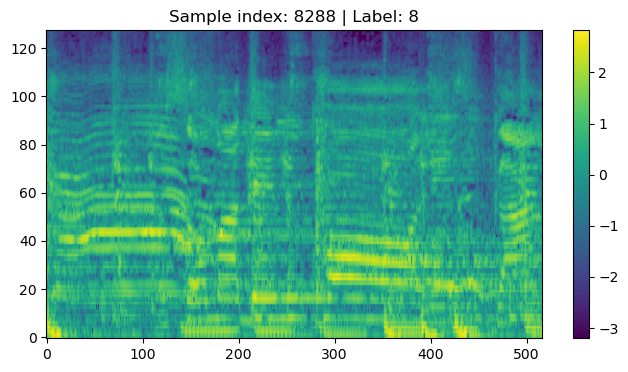

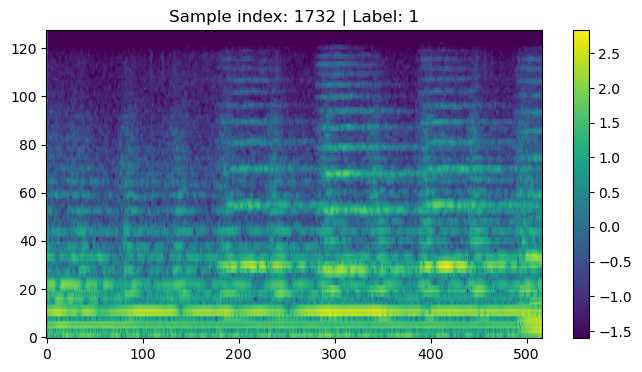

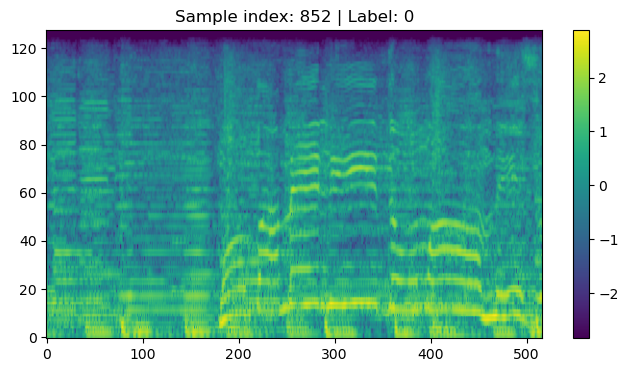

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

folder = "/Users/canpasa_macmini_2025/Desktop/New Paper GTZAN/extracted_features_with_segments_new/fft512_hop128_mel128_seg3"

X = np.load(f"{folder}/X.npy")
y = np.load(f"{folder}/y.npy")

for _ in range(3):
    i = random.randint(0, len(X)-1)
    plt.figure(figsize=(8, 4))
    plt.imshow(X[i, :, :, 0], aspect="auto", origin="lower")
    plt.title(f"Sample index: {i} | Label: {y[i]}")
    plt.colorbar()
    plt.show()